# NYC Motor Vehicle Collision Analysis

This notebook serves as a report for collision data from the NYC Open Data API, including crashes, vehicles, and persons involved.

**Data Sources:**
- Crashes: Basic collision information
- Vehicles: Detailed vehicle and driver data
- Persons: Individual-level injury and safety data

### Feel free to do some or all of the prompts listed below. We would love to see some data visualizations as well as tables

**We are more interested in what data you display and how you decide to display the data**

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import numpy as np

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load environment and connect to database
load_dotenv()
POSTGRES_URL = os.getenv('POSTGRES_URL')
if not POSTGRES_URL:
    raise RuntimeError('POSTGRES_URL not set in .env')

engine = create_engine(POSTGRES_URL)
print('✅ Connected to PostgreSQL!')

pd.options.display.max_rows = 60
pd.options.display.max_columns = 60
RATE_COLS = ['injury_rate', 'fatality_rate']

def _get_rates_and_counts(sql_table, rate_cols, group_col, schema="analytics", remove_null_grp=False, should_print=True):
    df = pd.read_sql_table(sql_table, conn, schema=schema)
    if remove_null_grp:
        df = df[df[group_col].notnull()]
    df = df.set_index(group_col)
    df_rates = df[rate_cols].transpose()
    df_counts = df.drop(rate_cols, axis=1).transpose()
    if should_print:
        print(f"Collision Summary By {group_col.title()} - Counts")
        print(df_counts)
        print(f"\nInjury and Fatality Rates by {group_col.title()}")
        print(df_rates)
        print("\n")
    return df_rates, df_counts

✅ Connected to PostgreSQL!


## 1. Overview - Collision Summary

total number of collisions, injuries, and fatalities for 2024 in NYC



In [2]:
with engine.connect() as conn:
    df = pd.read_sql_table("collision_summary", conn, schema="analytics")
    df_rates = df[RATE_COLS].transpose().rename(columns={0: 'Rate'})
    df_counts = df.drop(RATE_COLS, axis=1).transpose().rename(columns={0: 'Count'}).astype('int32')
    print("Collision Summary Counts - Overview")
    print(df_counts)
    print("\nInjury and Fatality Rates - Overview")
    print(df_rates)

Collision Summary Counts - Overview
                       Count
total_collisions       91315
injury_incidents       40040
fatal_incidents          252
total_persons_injured  54029
total_persons_killed     268
pedestrians_injured     9615
pedestrians_killed       124
cyclists_injured        5150
cyclists_killed           24
motorists_injured      37429
motorists_killed         111

Injury and Fatality Rates - Overview
                   Rate
injury_rate    0.438482
fatality_rate  0.002760


*Note that the injury and fatality rate refer to the proportion of collisions that had at least 1 injury or fatality (not the weighted number of people injured/killed rate).*

## 2. Geographic Analysis - Collisions by Borough

Incident summary by Borough 

Collision Summary By Borough - Counts
borough                BRONX  BROOKLYN  MANHATTAN  QUEENS  STATEN ISLAND  \
total_collisions       10033     22785      11903   17812           2697   
injury_incidents        4417      9994       4875    7633            985   
fatal_incidents           29        53         28      31             11   
total_persons_injured   6026     13152       5778    9940           1303   
total_persons_killed      33        53         32      31             11   
pedestrians_injured     1299      2644       1639    1988            235   
pedestrians_killed        11        31         22      16              6   
cyclists_injured         451      1486       1332     788             70   
cyclists_killed            4         8          3       4              0   
motorists_injured       4064      8411       2584    6775            976   
motorists_killed          17        12          6       9              5   

borough                  NaN  
total_collisions  

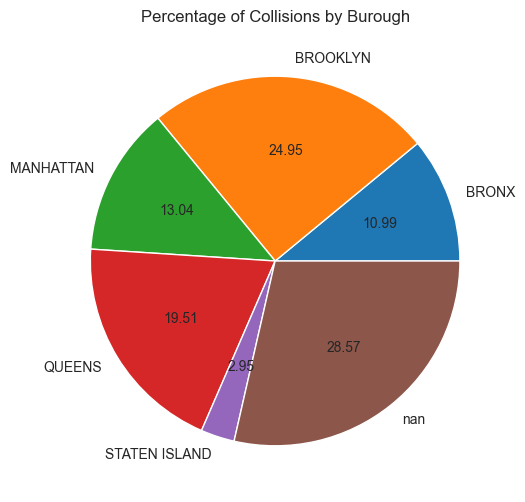

In [3]:
with engine.connect() as conn:
    _, b_cnts = _get_rates_and_counts("borough_summary", RATE_COLS, "borough")
    b_cnts.transpose().plot.pie(y='total_collisions', autopct='%.2f', legend=False, title='Percentage of Collisions by Burough')

## 3. Temporal Patterns - When Do Collisions Happen?

Are there days or times where incidents happen more frequently

*Note that crash hour is the military hour, rounded down. Ex. midnight up to 59 minutes past midnight are bucketed into crash hour 0, and so on.*

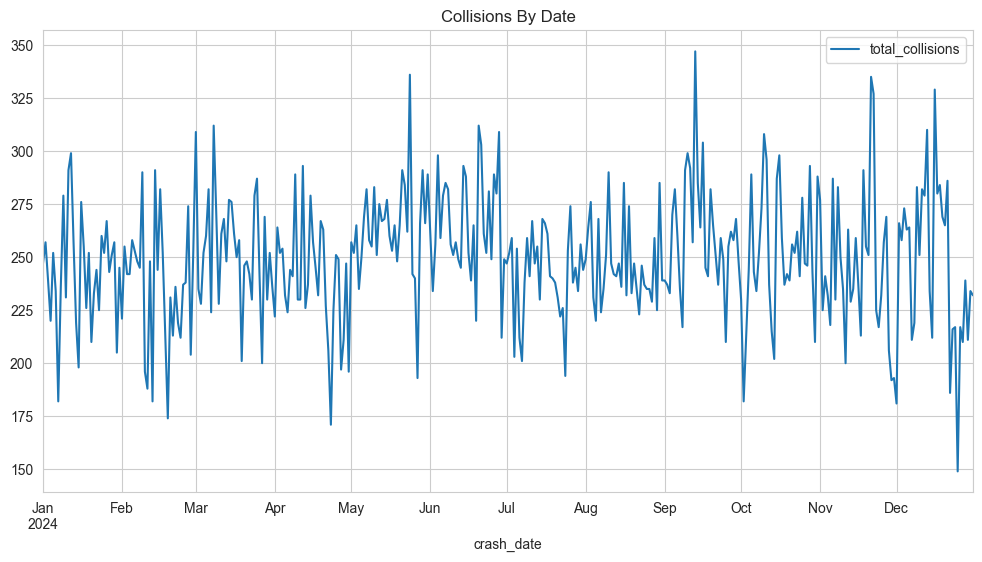

Collision Summary By Crash_Hour - Counts
crash_hour               0     1     2     3     4     5     6     7     8   \
total_collisions       4124  2258  1768  1579  1879  1903  2591  3380  4852   
injury_incidents       1678   859   609   578   666   682  1024  1398  1961   
fatal_incidents          14     9     8    12     9    15    16     3     7   
total_persons_injured  2467  1326   914   840   976   920  1344  1882  2528   
total_persons_killed     15    10     9    13    11    19    16     3     8   
pedestrians_injured     309   119    56    58    75    88   220   309   519   
pedestrians_killed        6     3     1     6     4    10     9     1     3   
cyclists_injured        168    73    46    42    32    55    98   134   231   
cyclists_killed           0     0     2     1     0     1     1     2     0   
motorists_injured      1915  1107   787   732   859   758   979  1382  1709   
motorists_killed          9     7     5     6     7     8     6     0     5   

crash_hour

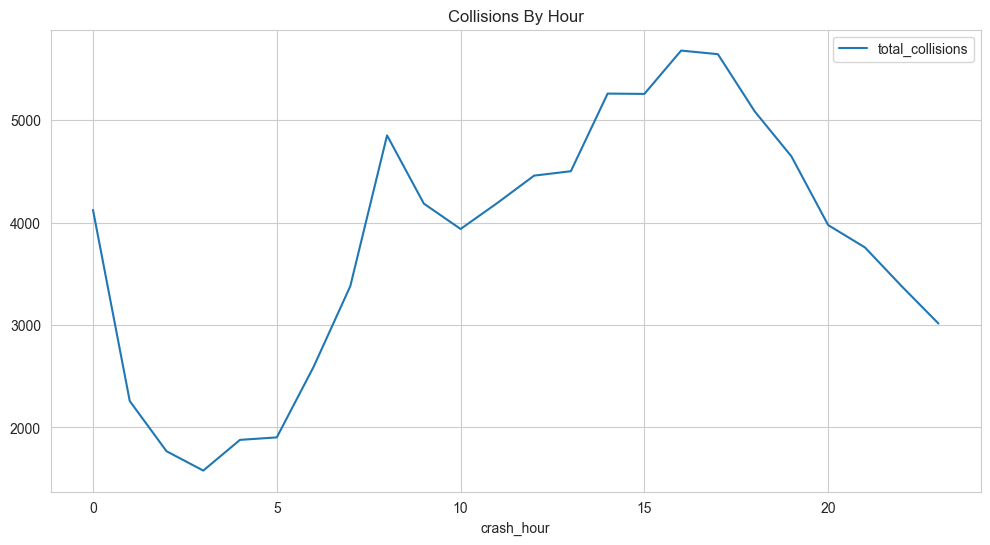

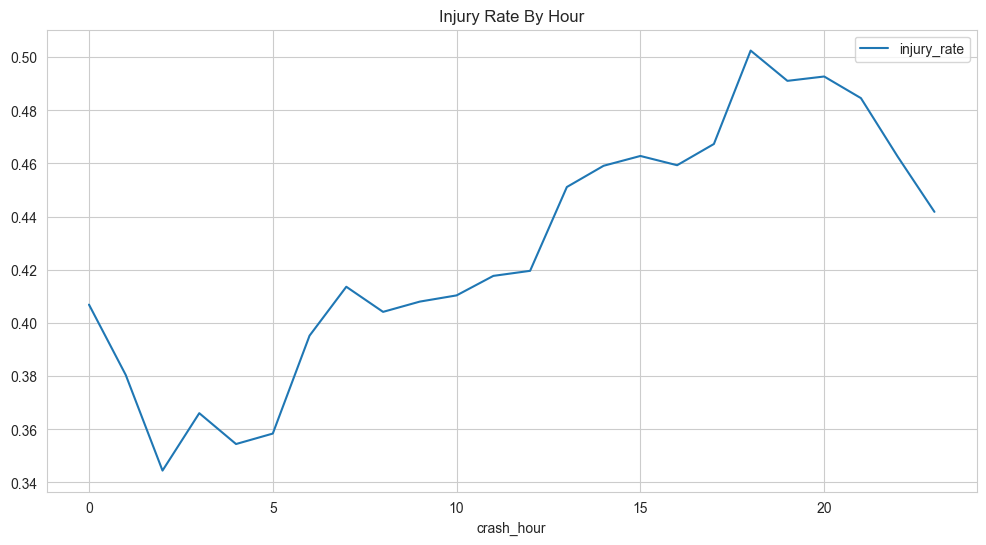

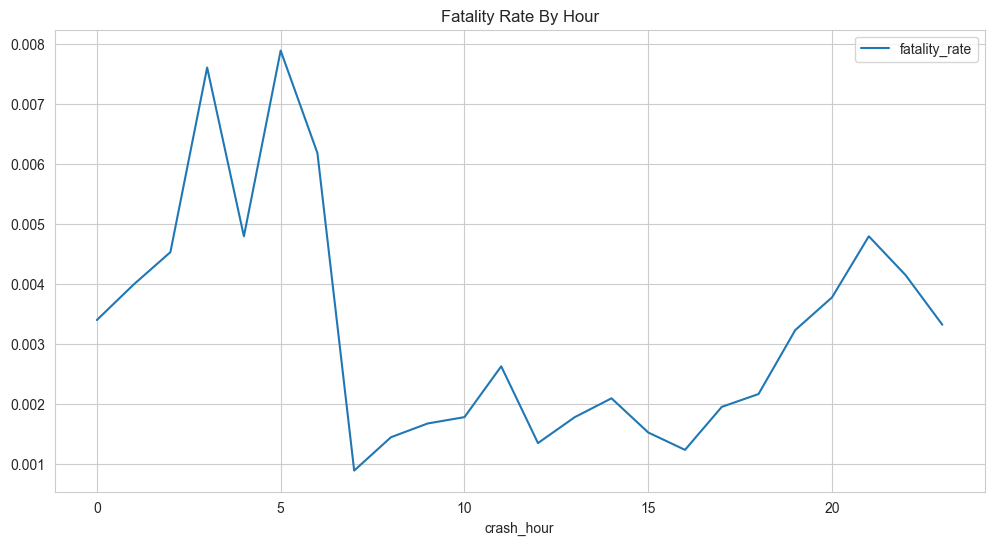

Collision Summary By Day_Of_Week - Counts
day_of_week           Sunday    Monday    Tuesday   Wednesday Thursday   \
day_of_week_num               1         2         3         4         5   
total_collisions          12138     13120     13270     12924     13135   
injury_incidents           5081      5712      5948      5915      5824   
fatal_incidents              31        35        34        38        27   
total_persons_injured      7345      7697      7843      7869      7569   
total_persons_killed         36        39        34        38        30   
pedestrians_injured         930      1407      1497      1579      1497   
pedestrians_killed           10        16        23        19        17   
cyclists_injured            625       706       792       784       729   
cyclists_killed               2         6         2         3         4   
motorists_injured          5570      5313      5304      5249      5063   
motorists_killed             22        17         9       

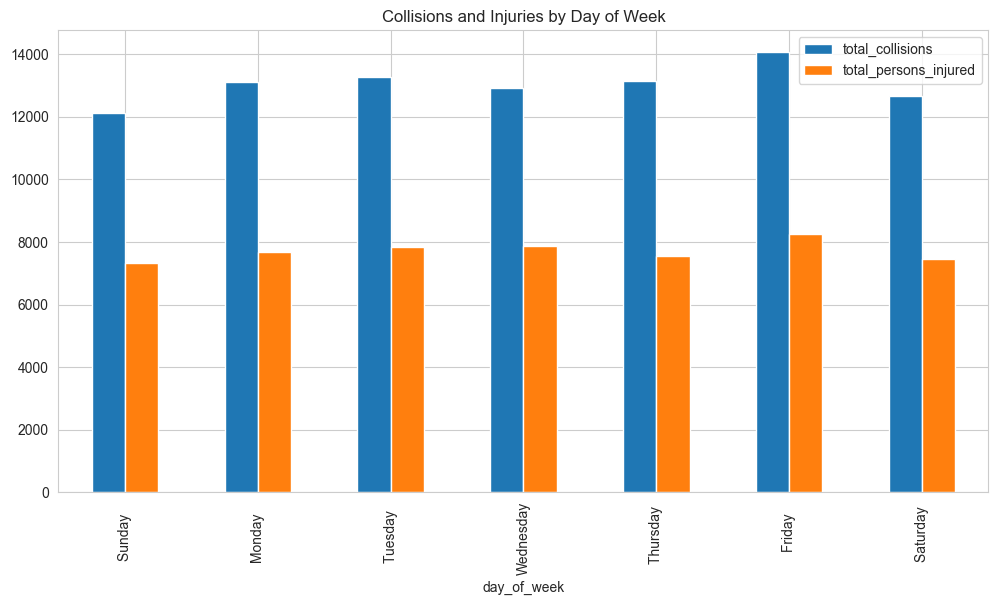

In [4]:
with engine.connect() as conn:
    date_rates, date_cnts = _get_rates_and_counts("date_summary", RATE_COLS, "crash_date", should_print=False)
    date_cnts = date_cnts.transpose().reset_index()
    date_cnts['crash_date'] = pd.to_datetime(date_cnts['crash_date'], format='%Y-%m-%dT00:00:00.000')
    date_cnts.plot.line(x='crash_date', y='total_collisions', title="Collisions By Date")
    plt.show()
    
    hour_rates, hour_cnts = _get_rates_and_counts("hourly_summary", RATE_COLS, "crash_hour")
    hour_cnts.transpose().reset_index().plot.line(x='crash_hour', y='total_collisions', title="Collisions By Hour")
    hour_rates.transpose().reset_index().plot.line(x='crash_hour', y='injury_rate', title="Injury Rate By Hour")
    hour_rates.transpose().reset_index().plot.line(x='crash_hour', y='fatality_rate', title="Fatality Rate By Hour")
    plt.show()
    
    day_rates, day_cnts = _get_rates_and_counts("day_of_week_summary", RATE_COLS, "day_of_week")
    day_cnts.transpose().reset_index().plot(kind="bar", x="day_of_week", y=['total_collisions', 'total_persons_injured'], title="Collisions and Injuries by Day of Week")
    plt.show()

## 4. Demographics - Whos is most likely 

Does sex, age, or person type factor in to vulnerability or likely hood of being involved?

I'm sure it does, but similarly to the caveats around vehicle type, it's difficult to draw any clear conclusions without knowing the demographics of all drivers/passengers on the road, rather than just knowing the demographics of those who are involved in collisions. The data only lets us make inferences in the case someone is already involved in a collision as to what their demographics/outcomes might be, as opposed to the other way around. 

Collision Summary By Person_Sex - Counts
person_sex                 F      M      U
total_collisions       47744  77823  33328
injury_incidents       23890  36217  13481
fatal_incidents          131    239    238
total_persons_injured  35378  49735  19649
total_persons_killed     145    255    254
pedestrians_injured     6059   7687   2750
pedestrians_killed        74    116    111
cyclists_injured        1830   4838   1322
cyclists_killed            9     24     24
motorists_injured      26783  35477  15169
motorists_killed          58    107    110

Injury and Fatality Rates by Person_Sex
person_sex            F         M         U
injury_rate    0.500377  0.465377  0.404495
fatality_rate  0.002744  0.003071  0.007141




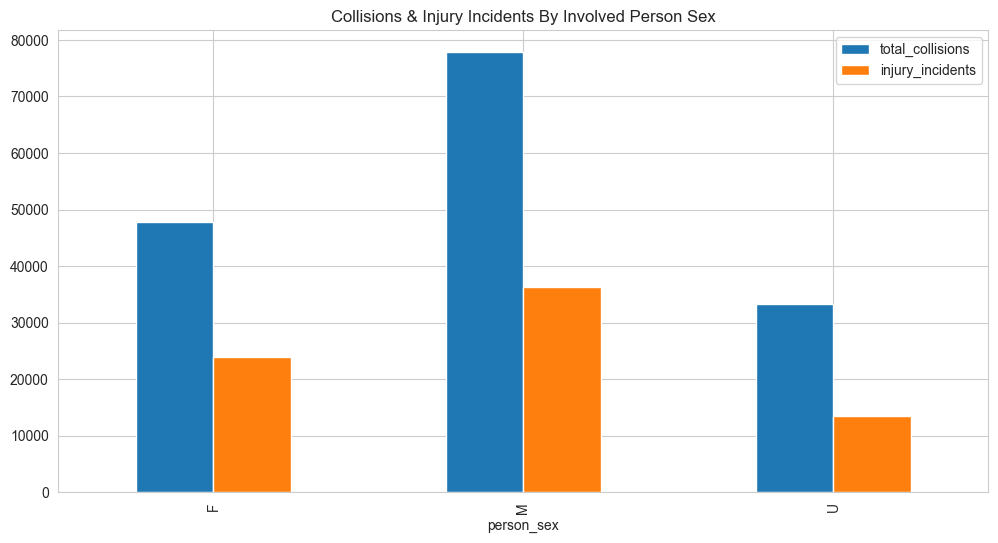

Collision Summary By Person_Type - Counts
person_type            OCCUPANT  PEDESTRIAN  BICYCLIST  OTHER MOTORIZED
total_collisions          86822        9893       6016             2039
injury_incidents          36210        9265       5255             1832
fatal_incidents             249         121         27               10
total_persons_injured     50025        9983       5501             1977
total_persons_killed        265         124         27               10
pedestrians_injured        7232        9615        224               75
pedestrians_killed          121         124          2                1
cyclists_injured           3924          69       5150               15
cyclists_killed              24           0         24                0
motorists_injured         37429         280        108               52
motorists_killed            111           0          0                0

Injury and Fatality Rates by Person_Type
person_type    OCCUPANT  PEDESTRIAN  BICYCLIST  OTHE

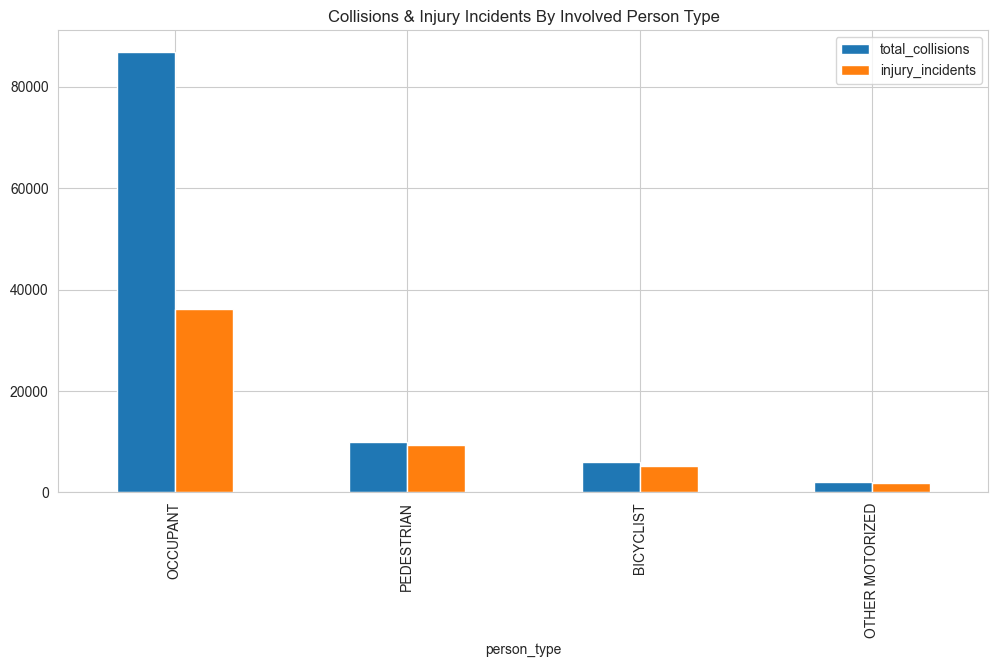

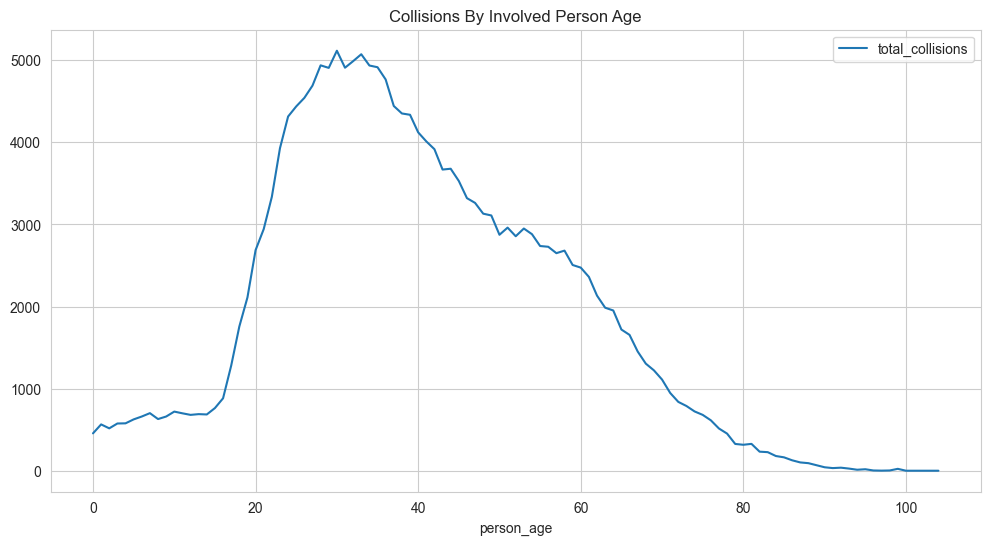

In [5]:
with engine.connect() as conn:
    _, sex_cnts = _get_rates_and_counts("sex_summary", RATE_COLS, "person_sex")
    sex_cnts.transpose().reset_index().plot(kind='bar', x='person_sex', y=['total_collisions', 'injury_incidents'], title="Collisions & Injury Incidents By Involved Person Sex")
    plt.show()
    
    _, pt_cnts = _get_rates_and_counts("person_type_summary", RATE_COLS, "person_type")
    pt_cnts.transpose().reset_index().plot(kind='bar', x='person_type', y=['total_collisions', 'injury_incidents'], title="Collisions & Injury Incidents By Involved Person Type")
    
    _, age_cnts = _get_rates_and_counts("person_age_summary", RATE_COLS, "person_age", should_print=False)
    age_cnts.transpose().reset_index().plot.line(x='person_age', y='total_collisions', title="Collisions By Involved Person Age")
    plt.show()

## 5. Vehicle Analysis - Vehicle Types and Safety

What vehicle types are more than likely to be in a crash and are there vehicles safer than others?

*Note that the tables below are ordered from vehicle type with the highest number of collisions to the lowest.*

It's difficult to say whether particular vehicles are safer than others, since to see the true relative likelihood of crashes with certain vehicles, we'd need to know what proportion of overall (non-crash) traffic those vehicle types make up. There are many vehicle types that were only involved in 1 collision, but that is likely just because they're rarer vehicles overall.

However, if we're looking at the vehicles with the lowest likelihood of injury and death when they do crash, see the last 2 graph in this section with the ordering of lowest injury and fatality rates (specifically restricted to vehicle_types that are associated with 100+ collisions, to not focus on vehicle types that are too rare to glean anything substantive from).

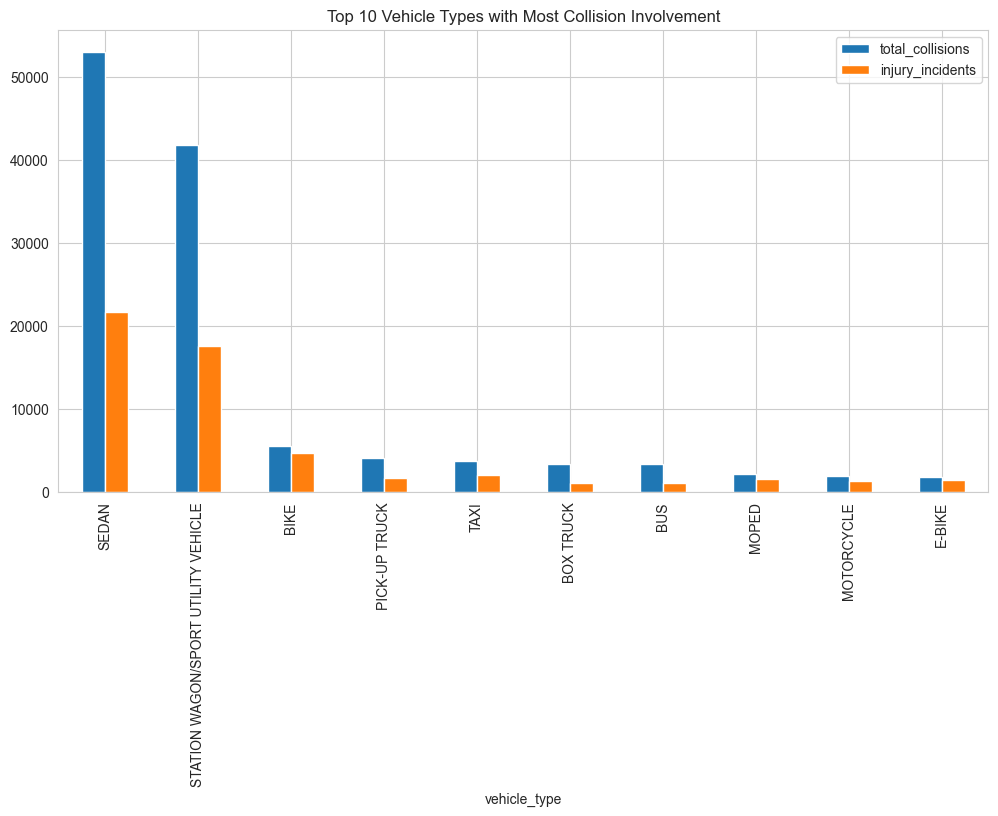

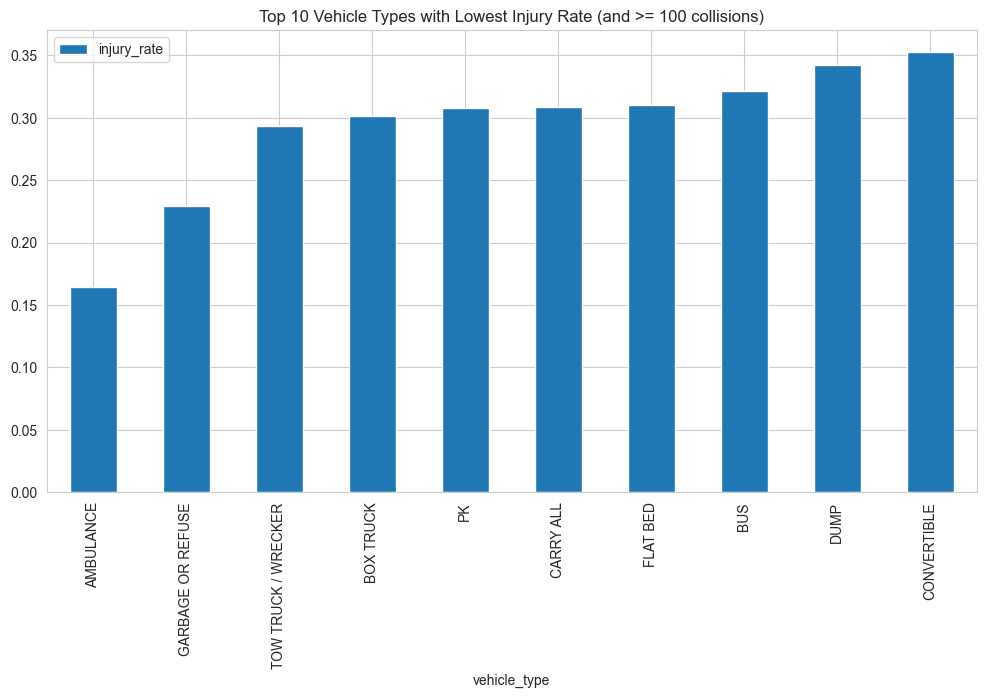

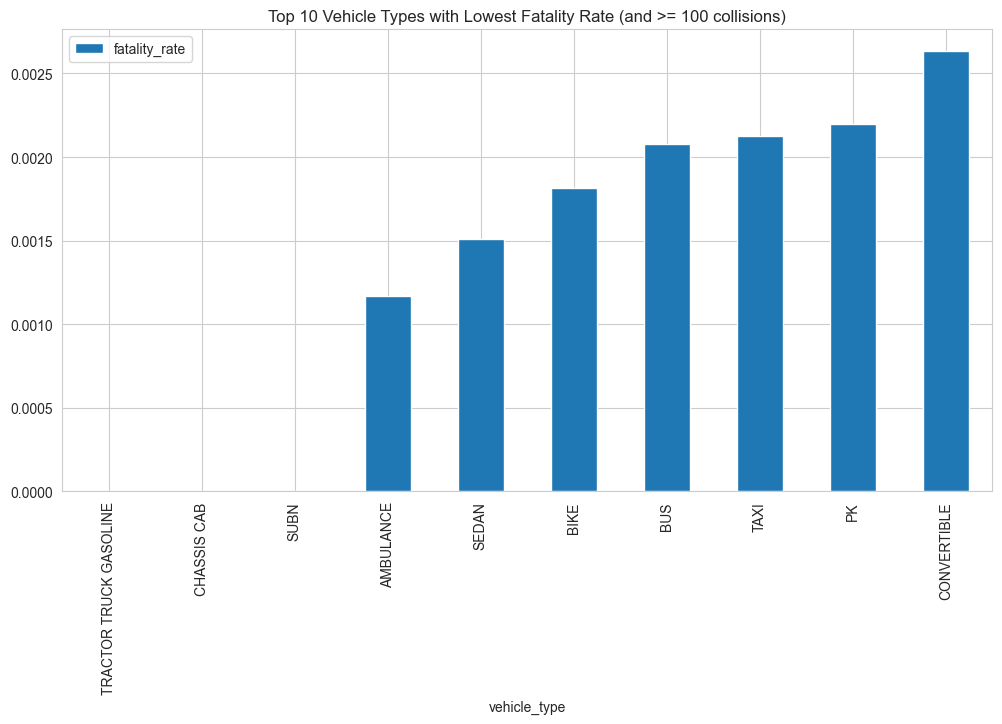

In [6]:
with engine.connect() as conn:
    vt_rates, vt_cnts = _get_rates_and_counts("vehicle_type_summary", RATE_COLS, "vehicle_type", remove_null_grp=True, should_print=False)
    vt_cnts.transpose().nlargest(10, 'total_collisions').plot(kind='bar', y=['total_collisions', 'injury_incidents'], title="Top 10 Vehicle Types with Most Collision Involvement")
    
    vt_rates, vt_cnts = vt_rates.transpose().reset_index(), vt_cnts.transpose().reset_index()
    sig_vts = vt_cnts[vt_cnts['total_collisions'] >= 100]['vehicle_type'].unique()
    vt_rates_sig = vt_rates[vt_rates['vehicle_type'].isin(sig_vts)]
    vt_rates_sig.nsmallest(10, 'injury_rate').plot(kind='bar', x='vehicle_type', y='injury_rate', title="Top 10 Vehicle Types with Lowest Injury Rate (and >= 100 collisions)")
    vt_rates_sig.nsmallest(10, 'fatality_rate').plot(kind='bar', x='vehicle_type', y='fatality_rate', title="Top 10 Vehicle Types with Lowest Fatality Rate (and >= 100 collisions)")
    plt.show()

## 7. Safety Equipment Analysis - Does It Save Lives?

Does safety equipemnt make a difference?

Much of the data doesn't include conclusive data on safety equipment, marking either "other" or NaN (aka null) equipment in use. Other and NaN actually have the lowest injury rates, but a couple other types of safety equipments correspond to lower fatality rates--though the size/cleanliness of the data makes me not very confident to draw conclusions either way. 


Collision Summary By Safety_Equipment - Counts
safety_equipment       HARNESS  STOPPERS ONLY (IN-LINE SKATER/BICYCLIST)  \
total_collisions           481                                        25   
injury_incidents           240                                        17   
fatal_incidents              0                                         0   
total_persons_injured      390                                        29   
total_persons_killed         0                                         0   
pedestrians_injured         36                                         2   
pedestrians_killed           0                                         0   
cyclists_injured            26                                         6   
cyclists_killed              0                                         0   
motorists_injured          323                                        21   
motorists_killed             0                                         0   

safety_equipment       PADS ONLY (IN-LIN

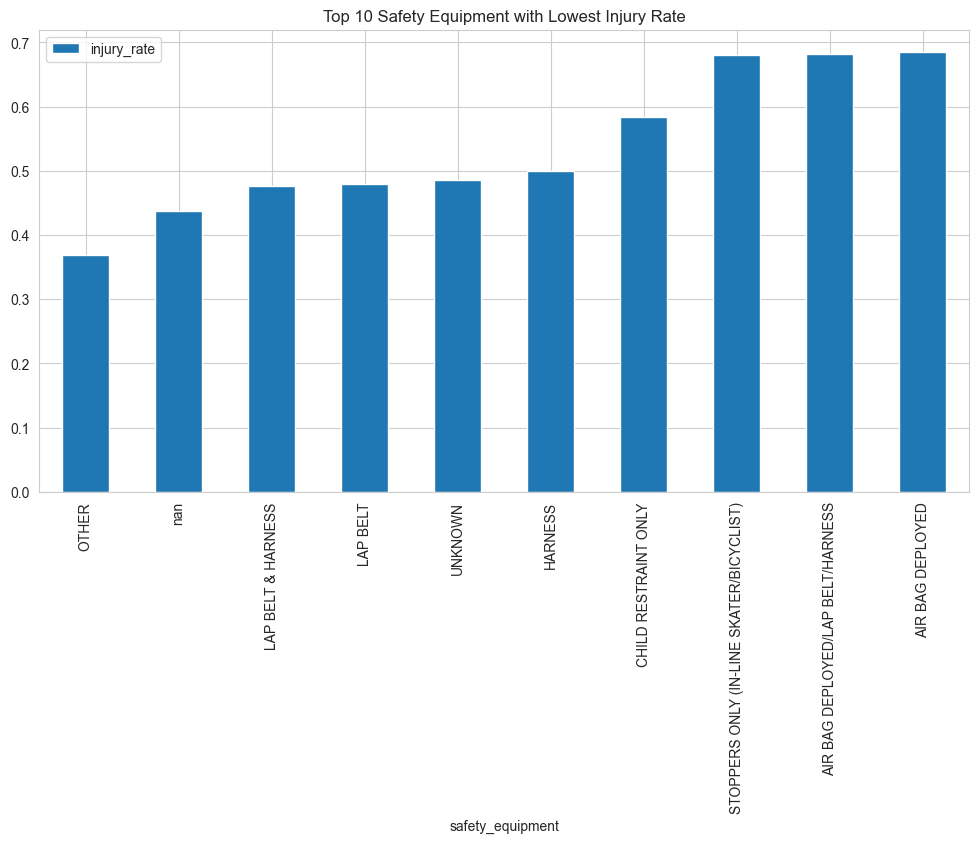

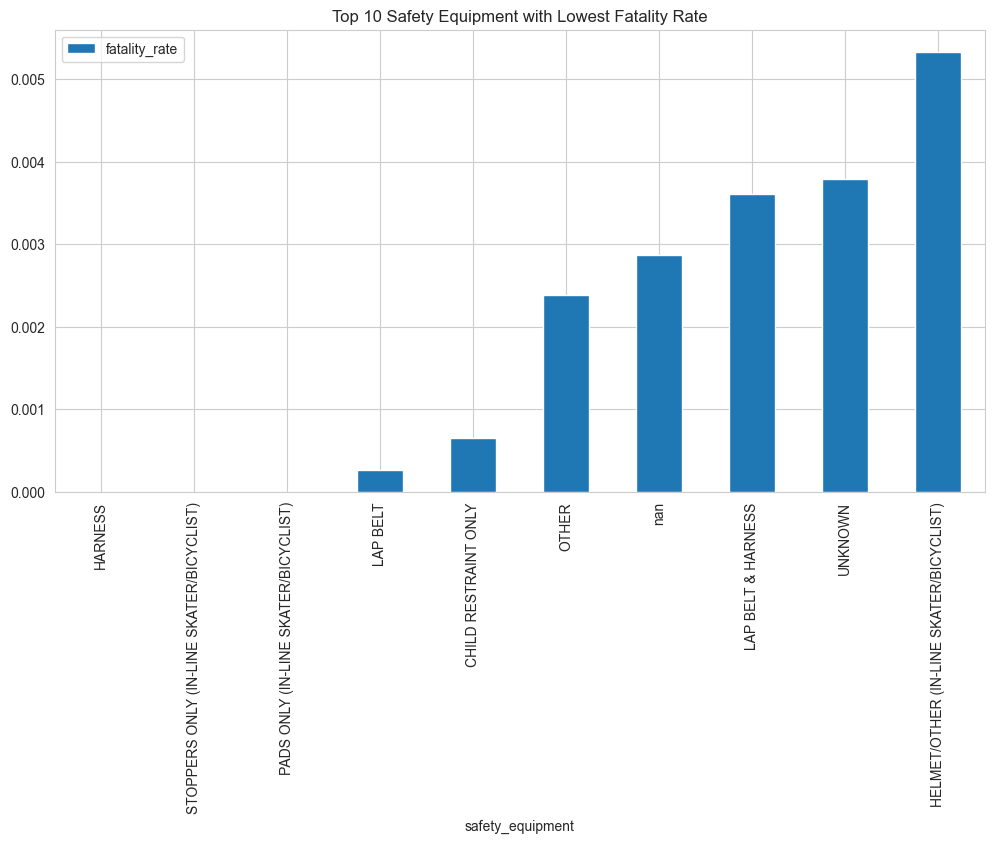

In [7]:
with engine.connect() as conn:
    se_rates, _ = _get_rates_and_counts("safety_equip_summary", RATE_COLS, "safety_equipment")
    se_rates.transpose().nsmallest(10, 'injury_rate').plot(kind='bar', y='injury_rate', title="Top 10 Safety Equipment with Lowest Injury Rate")
    se_rates.transpose().nsmallest(10, 'fatality_rate').plot(kind='bar', y='fatality_rate', title="Top 10 Safety Equipment with Lowest Fatality Rate")

## 8. Contributing Factors - What Causes Collisions?

Collision Summary By Contributing_Factor - Counts
contributing_factor    ACCELERATOR DEFECTIVE  AGGRESSIVE DRIVING/ROAD RAGE  \
total_collisions                          61                           945   
injury_incidents                          26                           371   
fatal_incidents                            1                             1   
total_persons_injured                     38                           541   
total_persons_killed                       1                             1   
pedestrians_injured                        6                           120   
pedestrians_killed                         1                             0   
cyclists_injured                           0                            18   
cyclists_killed                            0                             0   
motorists_injured                         32                           395   
motorists_killed                           0                             1   

contributing_

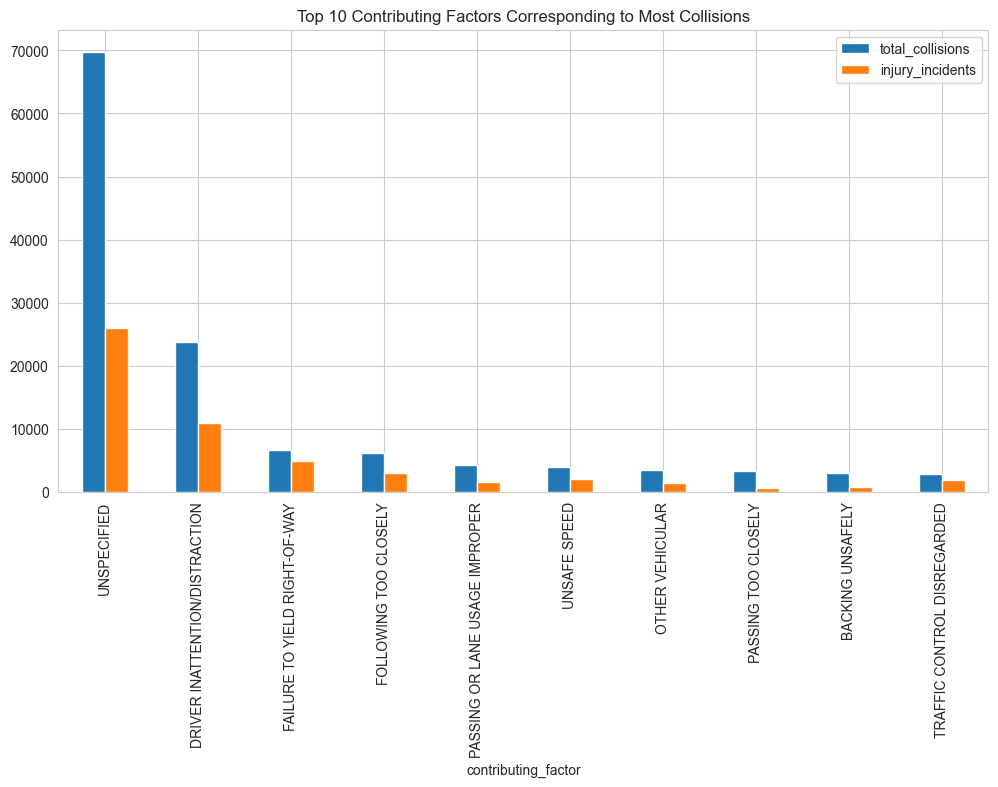

In [8]:
with engine.connect() as conn:
    cf_rates, cf_cnts = _get_rates_and_counts("contrib_factor_breakdown", RATE_COLS, "contributing_factor")
    cf_cnts.transpose().nlargest(10, 'total_collisions').plot(kind='bar', y=['total_collisions', 'injury_incidents'], title="Top 10 Contributing Factors Corresponding to Most Collisions")
    plt.show()